# MACHINE LEARNING 2026 - FINAL PROJECT (Option 1)

Course 2025/26: *C. Sun*, *M. Pavan*, *P. Zanuttigh*  

**Group Members:**        
*`Tommaso Dambi ID:2141118`*         
*`Alessandro Costabile ID:2146702`*        
*`Carlo Toffoli ID:2144522`*

## Heart Disease Analysis Using Clustering and Classification
<center>
    <img src="data/dataset-cover.jpg" style = "width: 50%;">
</center>

The dataset labels are the following:

|   id| age   | sex | dataset | cp | trestbps | chol | fbs | restecg | thalch | exang | oldpeak |slope | ca | thal | num |
| :-: | :-:  |  :-: | :-: | :-:| :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: | :-: |
| 1  |  63   | Male | Cleveland | typical angina | 145 | 233 | TRUE | Iv hypertrophy | 150 | FALSE | 2.3 | downsloping | 0 | fixed defect | 0 |
| 2  | 67   | Male | Cleveland | asymptomatic | 160 | 286 | FALSE | Iv hypertrophy | 108 | TRUE | 1.5 | flat | 3 | normal | 1 |
| 3   | 67 | Male | Cleveland | asymptomatic | 120 | 229 | FALSE | Iv hypertrophy | 129 | TRUE | 2.6 | flat | 2 | reversable | 2 |
| 4   | 37| Male | Cleveland | non-anginal | 130 | 250 | FALSE | normal | 187 | FALSE | 3.5 | downsloping | 0 | normal | 3 |

Description of the features:
 - `cp`: chest pain type:
    1. typical angina
    2. atypical angina
    3. non-anginal pain
    4. asymptomatic
 - `trestbps`: resting blood pressure (in mm Hg on admission to the hospital)
 - `chol`: serum cholestoral [mg/dL]
 - `fbs`: fasting blood sugar (True if above 120 mg/dL)
 - `restecg`: resting electrocardiographic results
    1. having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    2. showing probable or definite left ventricular hypertrophy by Estes' criteria
    3. normal
 - `thalch`: maximum heart rate achieved
 - `exang`: exercise induced angina
    1. yes
    2. no
 - `oldpeak`: ST depression induced by exercise relative to rest
 - `slope`: the slope of the peak exercise ST segment
    1. upsloping
    2. flat
    3. downsloping
 - `ca`: number of major vessels (0-3) colored by flouroscopy
 - `thal`: type of defect in blood flow towards heart
    1. fixed defect
    2. reversable
    3. normal
 - `num`: label - severity of the disease from 0 (not present) to 4 (max severity)

Some records lack of data of some features such as `trestbps`, `chol`, `fbs`, `thalch`, `exang`, `oldpeak`, `ca`. This has to be addressed, maybe with clustering?

# Documentation used
- [Numpy](https://numpy.org/doc/stable/reference/index.html#reference)
- [Pandas](https://pandas.pydata.org/docs/reference/index.html#api)
- [Scikit-learn](https://scikit-learn.org/stable/api/index.html)

# ⚠️ OCIO
Il dataset non è incluso per ovvi motivi nel repository github. Scaricalo, estrailo e mettilo nella cartella `/data`. Ricorda di aggiornare il nome del file!
Also: the jupyter server was launched from the upper dir of the project (tdc_fp/..). All the relative imports were done accordingly.

# CODE

## Imports

In [ ]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tdc_fp.preproc import (
    load_dataset, split_dataset, filter_dataset, 
    encode_feature, standardize, binarize
)
from seaborn import pairplot, heatmap
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from supervised import algo_selection
# from sklearn.decomposition import PCA
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, accuracy_score

ID = 2144522
np.random.seed(ID)

## 1. Data Preprocessing
All the preprocessing helper functions are defined in `preproc.py`.
As many samples lack the significant `ca` feature we have decided to use just the Cleveland data which provides that feature in almost all the samples.

In [10]:
# TODO: Dropping columns when loading the dataset isn't ideal, move it to another function
# (we will use it to control the number of features)
csv_dataframe = load_dataset('tdc_fp/data/heart_disease_uci.csv', drop_columns=['id']) # tried dropping `ca` because 611 samples were missing it

# print(csv_dataframe.head())

enc = OrdinalEncoder()
dataset = enc.fit_transform(csv_dataframe.to_numpy())
value_map = enc.categories_

# dataset, value_map = encode_feature(csv_dataframe) # Old code - value map is list of list!

# Print the mapped array
print("Dataset is:")
print(dataset.dtype, dataset.shape)

# Deal with nan values BEFORE STANDARDIZATION (issue #2)

# First filter: keep only clean samples from Cleveland
# dataset_filtered = filter_dataset(dataset, lambda x: not np.isnan(x[1]).any() and x[1][2] == np.where(value_map[2] == "Cleveland"))
dataset_filtered = filter_dataset(dataset.T, lambda x: x[0] not in (12,13)).T
dataset_filtered = filter_dataset(dataset_filtered, lambda x: not np.isnan(x[1]).any())
# Second filter: all the samples are from Cleveland, drop that column!
# column 2 is the dataset column
print("\nFiltered dataset is:")
print(dataset_filtered.dtype, dataset_filtered.shape)

X, Y = split_dataset(dataset_filtered)
print("\nX and Y shapes after filtering:")
print(X.shape, Y.shape)

# Comment this code if you're trying to do multiclass classification
Y = binarize(Y)

# A dataframe is useful for visualization
# dataframe = pd.DataFrame(X)
# dataframe["target"] = Y
# feature_names = csv_dataframe.columns.tolist()
# feature_names.remove("dataset")
# feature_names.remove("num")
# feature_names.append("target")
# dataframe.columns = feature_names

# pairplot(dataframe, hue="target", corner=True)
# plt.savefig("pairplot.jpg")

# Standardization
X = standardize(X)

# If you want to take a look to the correlation factor between the single features and the label:
# print(np.corrcoef(X.T[9], Y.ravel()))

print(f"\nUnique values of Y: {np.unique(Y)}")
print()
print(pd.DataFrame(X).describe().round(3))

Dataset is:
float64 (920, 15)

Filtered dataset is:
float64 (531, 13)

X and Y shapes after filtering:
(531, 12) (531, 1)

Unique values of Y: [0 1]

            0        1        2        3        4        5        6        7   \
count  531.000  531.000  531.000  531.000  531.000  531.000  531.000  531.000   
mean    -0.000    0.000    0.000    0.000    0.000    0.000   -0.000   -0.000   
std      1.001    1.001    1.001    1.001    1.001    1.001    1.001    1.001   
min     -2.932   -1.784   -0.743   -0.744   -2.669   -1.576   -0.437   -1.298   
25%     -0.663    0.561   -0.743   -0.744   -0.805   -0.670   -0.437   -1.298   
50%      0.131    0.561   -0.743   -0.744   -0.042   -0.017   -0.437    0.258   
75%      0.698    0.561    0.578    1.292    0.551    0.708   -0.437    0.258   
max      2.513    0.561    1.900    2.310    2.416    2.339    2.291    1.813   

            8        9        10       11  
count  531.000  531.000  531.000  531.000  
mean    -0.000   -0.000    0.000

In [ ]:
# print(feature_names)
# heatmap(data=dataframe.corr(), cmap="crest")
# plt.savefig("heatmap.jpg")

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 2. Clustering analisys

Va capita l'utilità di questa cosa: una volta trovati i cluster cosa ce ne facciamo? Vogliamo classificare in maniera unsupervised? boh
Ok, poi devo farlo prima del PCA? PCA serve solo a visualizzare i dati o posso anche comprendere se una componente in particolare ha la giusta combinazione di features che permette una classificazione lineare?

In [ ]:
# Dataset split
permuted_indexes = np.random.permutation(X.shape[0])

X = X[permuted_indexes]
Y = Y[permuted_indexes]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=ID)

Accuracy: 26.26 %
Accuracy with inverted labels: 19.87 %


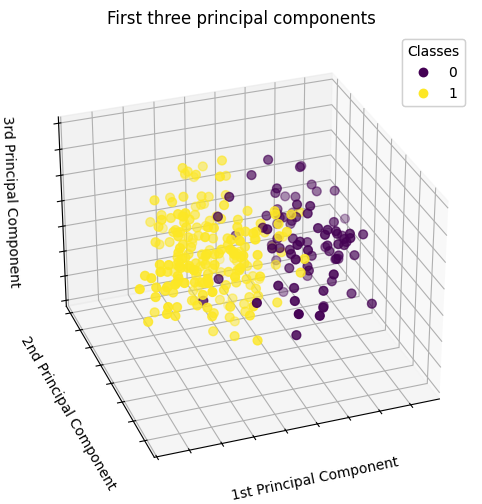

In [ ]:
# For what concerns visualization, we need to decompose the data into at most 3 components
# (plus the labels which are represented by the color of the datapoints)

# Sample code
from sklearn.decomposition import PCA

def scatter_plot(data: np.ndarray, clusters: np.ndarray = None, centers: np.ndarray = None, title: str = None) -> None:
    """
    Plot a scatter plot of the data
    :param data: data to plot
    :param clusters: cluster labels
    :param centers: cluster centers
    :param title: title of the plot
    """
    
    fig = plt.figure()
    axis = fig.add_subplot(1, 1, 1, projection="3d")
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
    axis.set_zlabel("Component 3", rotation=90, labelpad=-1)
    if title is not None:
        plt.title(title)
    if clusters is None:
        axis.scatter(data[:,0], data[:,1], data[:,2], marker="o", c=data, s=5)
    else:
        axis.scatter(data[:,0], data[:,1], data[:,2], marker="o", c=clusters, s=1, cmap='viridis', zorder=0, alpha=0.5 )
    if centers is not None:
        axis.scatter(centers[:,0], centers[:,1], centers[:,2], c='red', s=400, zorder=10)
    plt.tight_layout()
    plt.show()
    plt.close()

# Do clustering into two clusters
# clustering = KMeans(2, n_init=10).fit(X)
clustering = AgglomerativeClustering(2, linkage='ward').fit(X)

labels = clustering.labels_
inverted_labels = np.invert(clustering.labels_.astype(bool)).astype(int)

# Compute the score manually: 
# just do the dot product between the two arrays and divide the result by the number of samples
def manual_score(cluster_labels, y) -> float:
    return np.dot(cluster_labels, y)[0] / y.shape[0]

print("Accuracy:", round(manual_score(clustering.labels_, Y)*100, 2), "%")
print("Accuracy with inverted labels:", round(manual_score(inverted_labels, Y)*100, 2), "%")

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(X)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=pd.Series(inverted_labels.ravel()),
    s=40,
)

ax.set(
    title="First three principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(Y).tolist(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

## 3. Supervised Learning

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Call the algorithm selection function
algo_selection(X_train, X_test, y_train, y_test, ID)
# - Precision: di quelli che ho pedetto malati, quanti lo sono davvero
# - Recall: dei malati veri, quanti ne ho beccati
# - F1: media di precision e recall
print("Test set results: ",
    "\nAccurancy: ", round(accuracy_score(y_test, y_pred), 3),
    "\nPrecision: ", round(precision_score(y_test, y_pred), 3),
    "\nRecall: ", round(recall_score(y_test, y_pred), 3))